In [1]:
import sys
from pathlib import Path

# Save the notebook's OutStream BEFORE importing train.py, which replaces
# sys.stdout/stderr with raw file-descriptor wrappers (for DDP line-buffering).
# Those wrappers call fileno() on the notebook's OutStream, grab fd=1 (the
# terminal), and redirect all prints away from the cell output.
_nb_stdout = sys.stdout
_nb_stderr = sys.stderr

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython import get_ipython
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from train import ExpressionPerformer

# Restore notebook output streams after train.py import side effects.
sys.stdout = _nb_stdout
sys.stderr = _nb_stderr

# Ensure inline plotting backend in notebook.
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
try:
    plt.switch_backend("module://matplotlib_inline.backend_inline")
except Exception:
    pass
matplotlib.rcParams["figure.dpi"] = 110

sns.set_theme(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RUN_DIR = ROOT / "checkpoints_performer/20jo1hdd"
CHECKPOINT_PATH = RUN_DIR / "best_model.pt"
CANONICAL_GENES_PATH = ROOT / "data/archs4/train_orthologs/canonical_genes.csv"

assert CHECKPOINT_PATH.exists(), f"Missing checkpoint: {CHECKPOINT_PATH}"
assert CANONICAL_GENES_PATH.exists(), f"Missing canonical genes: {CANONICAL_GENES_PATH}"


def build_expression_performer(cfg, num_genes, device):
    model = ExpressionPerformer(
        num_genes=num_genes,
        hidden_dim=cfg["hidden_dim"],
        n_heads=cfg["num_heads"],
        n_layers=cfg["num_layers"],
        ffn_dim=cfg["ffn_dim"],
        ree_base=cfg["ree_base"],
        mask_token_id=cfg.get("mask_token", -10),
        feature_type=cfg.get("feature_type", "sqr"),
        compute_type=cfg.get("compute_type", "iter"),
    )
    return model.to(device).eval()


def encode_hidden_states(model, x):
    _, num_genes = x.shape
    gene_ids = torch.arange(num_genes, device=x.device)
    gene_emb = model.gene_embedding(gene_ids)
    ree_emb = model.ree(x)
    hidden = gene_emb.unsqueeze(0) + ree_emb
    for layer in model.layers:
        rfs = layer.attention.sample_rfs(x.device)
        hidden = layer.full_forward(hidden, rfs)
    return hidden


payload = torch.load(CHECKPOINT_PATH, map_location="cpu")
cfg = payload["config"]
gene_order = pd.read_csv(CANONICAL_GENES_PATH)["gene_symbol"].astype(str).tolist()

expected_num_genes = int(payload["model_state_dict"]["gene_embedding.weight"].shape[0])
assert len(gene_order) == expected_num_genes, (
    f"Gene list/checkpoint mismatch: {len(gene_order)} vs {expected_num_genes}"
)

model = build_expression_performer(cfg, num_genes=len(gene_order), device=device)
model.load_state_dict(payload["model_state_dict"])
model.eval()

print(f"Loaded model on {device}")
print(f"Genes: {len(gene_order)}")

Loaded model on cuda
Genes: 15165


Zero-input hidden shape: (15165, 512)
Cluster sizes:
cluster
0     832
1     962
2     858
3     786
4     854
5     779
6     661
7     590
8     275
9     696
10    836
11    808
12    881
13    621
14    689
15    731
16    842
17    819
18    775
19    870


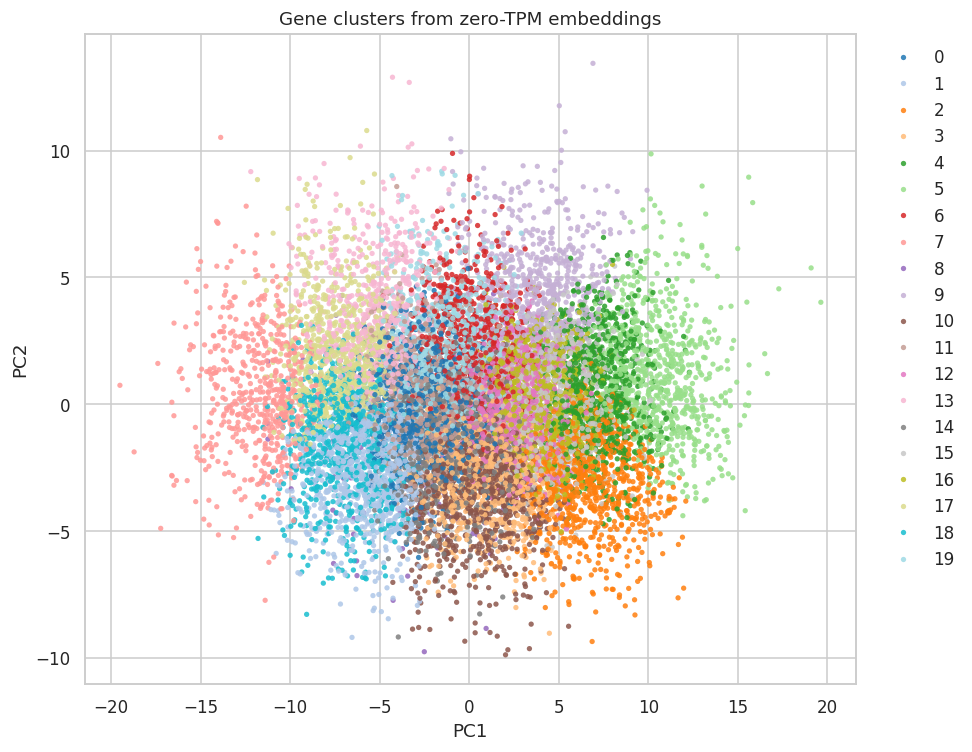

,gene,cluster
0,A1CF,8
1,A2M,8
2,A3GALT2,8
3,A4GALT,8
4,A4GNT,8


In [2]:
# 1) Extract per-gene embeddings when all TPM values are zero
zero_expr = torch.zeros((1, len(gene_order)), dtype=torch.float32, device=device)

with torch.no_grad():
    zero_hidden = encode_hidden_states(model, zero_expr)[0].detach().cpu().numpy()  # [G, D]

print(f"Zero-input hidden shape: {zero_hidden.shape}")

# 2) Cluster genes by embedding similarity
N_CLUSTERS = 20
EMBEDDING_FOR_CLUSTER = StandardScaler().fit_transform(zero_hidden)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
cluster_id = kmeans.fit_predict(EMBEDDING_FOR_CLUSTER)

gene_cluster_df = pd.DataFrame(
    {
        "gene": gene_order,
        "cluster": cluster_id,
    }
)

cluster_sizes = gene_cluster_df["cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes.to_string())

# 3) Visualize clusters in PCA-2D
pca2 = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(EMBEDDING_FOR_CLUSTER)
plot_df = pd.DataFrame(
    {
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "cluster": cluster_id,
    }
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab20",
    s=12,
    linewidth=0,
    alpha=0.85,
    ax=ax,
)
ax.set_title("Gene clusters from zero-TPM embeddings")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1, frameon=False)
plt.tight_layout()
plt.show()

gene_cluster_df.head()

In [3]:
# 4) KEGG / GO pathway enrichment for each cluster
# Uses Enrichr via gseapy. If network is unavailable, this cell prints a clear message.
import gseapy as gp

ENRICHR_LIBRARIES = [
    "KEGG_2021_Human",
    "GO_Biological_Process_2023",
]

MIN_GENES_PER_CLUSTER = 20
MAX_GENES_PER_CLUSTER = 5000
TOP_TERMS = 5

enrichment_rows = []

for cl in sorted(gene_cluster_df["cluster"].unique()):
    genes = gene_cluster_df.loc[gene_cluster_df["cluster"] == cl, "gene"].dropna().astype(str).unique().tolist()

    if len(genes) < MIN_GENES_PER_CLUSTER or len(genes) > MAX_GENES_PER_CLUSTER:
        enrichment_rows.append(
            {
                "cluster": int(cl),
                "library": "SKIPPED",
                "term": "cluster size outside analysis bounds",
                "adj_p": np.nan,
                "combined_score": np.nan,
                "overlap": np.nan,
                "n_genes": len(genes),
            }
        )
        continue

    for lib in ENRICHR_LIBRARIES:
        try:
            enr = gp.enrichr(
                gene_list=genes,
                gene_sets=lib,
                organism="Human",
                outdir=None,
                no_plot=True,
            )
            if enr.results is None or enr.results.empty:
                enrichment_rows.append(
                    {
                        "cluster": int(cl),
                        "library": lib,
                        "term": "no significant terms",
                        "adj_p": np.nan,
                        "combined_score": np.nan,
                        "overlap": np.nan,
                        "n_genes": len(genes),
                    }
                )
                continue

            top = enr.results.sort_values("Adjusted P-value", ascending=True).head(TOP_TERMS)
            for _, row in top.iterrows():
                enrichment_rows.append(
                    {
                        "cluster": int(cl),
                        "library": lib,
                        "term": str(row.get("Term", "")),
                        "adj_p": float(row.get("Adjusted P-value", np.nan)),
                        "combined_score": float(row.get("Combined Score", np.nan)),
                        "overlap": str(row.get("Overlap", "")),
                        "n_genes": len(genes),
                    }
                )
        except Exception as exc:
            enrichment_rows.append(
                {
                    "cluster": int(cl),
                    "library": lib,
                    "term": f"enrichment failed: {exc}",
                    "adj_p": np.nan,
                    "combined_score": np.nan,
                    "overlap": np.nan,
                    "n_genes": len(genes),
                }
            )


enrichment_df = pd.DataFrame(enrichment_rows)

if enrichment_df.empty:
    print("No enrichment results produced.")
else:
    print("Top enrichment hits by cluster:")
    display(enrichment_df.sort_values(["cluster", "library", "adj_p"], na_position="last").head(100))

# Optional quick summary: best adjusted p-value per cluster/library
if not enrichment_df.empty and "adj_p" in enrichment_df.columns:
    summary_df = (
        enrichment_df.dropna(subset=["adj_p"])
        .sort_values("adj_p")
        .groupby(["cluster", "library"], as_index=False)
        .first()
        [["cluster", "library", "term", "adj_p", "combined_score", "n_genes"]]
        .sort_values(["cluster", "library"])
    )
    print("\nBest term per cluster/library:")
    display(summary_df.head(100))

Top enrichment hits by cluster:


,cluster,library,term,adj_p,combined_score,overlap,n_genes
5,0,GO_Biological_Process_2023,Negative Regulation Of Cell Population Prolife...,0.093347,22.025664,33/379,832
6,0,GO_Biological_Process_2023,Regulation Of Phosphatidylinositol 3-Kinase Si...,0.093347,36.820862,13/90,832
7,0,GO_Biological_Process_2023,Regulation Of Cell Population Proliferation (G...,0.093347,16.354567,54/766,832
8,0,GO_Biological_Process_2023,Positive Regulation Of Phosphatidylinositol 3-...,0.093347,39.806352,11/69,832
9,0,GO_Biological_Process_2023,Phosphatidylinositol Metabolic Process (GO:004...,0.156478,36.318059,10/63,832
...,...,...,...,...,...,...,...
90,9,KEGG_2021_Human,Parkinson disease,0.023368,22.479026,21/249,696
91,9,KEGG_2021_Human,Huntington disease,0.023368,20.610231,24/306,696
92,9,KEGG_2021_Human,Pathways of neurodegeneration,0.023368,16.610407,32/475,696
93,9,KEGG_2021_Human,Bacterial invasion of epithelial cells,0.023368,33.592459,10/77,696



Best term per cluster/library:


,cluster,library,term,adj_p,combined_score,n_genes
0,0,GO_Biological_Process_2023,Negative Regulation Of Cell Population Prolife...,9.334742e-02,22.025664,832
1,0,KEGG_2021_Human,ECM-receptor interaction,3.816756e-02,30.092482,832
2,1,GO_Biological_Process_2023,Central Nervous System Neuron Differentiation ...,2.912122e-02,93.768750,962
3,1,KEGG_2021_Human,Neuroactive ligand-receptor interaction,5.845533e-03,24.875014,962
4,2,GO_Biological_Process_2023,Positive Regulation Of DNA-templated Transcrip...,4.030986e-03,24.514822,858
5,2,KEGG_2021_Human,Acute myeloid leukemia,1.588576e-01,29.705125,858
6,3,GO_Biological_Process_2023,Carbohydrate Biosynthetic Process (GO:0016051),1.078815e-01,97.937697,786
7,3,KEGG_2021_Human,Glycosaminoglycan biosynthesis,1.588583e-03,78.558632,786
8,4,GO_Biological_Process_2023,Positive Regulation Of Signal Transduction (GO...,9.223479e-02,26.929752,854
9,4,KEGG_2021_Human,Amphetamine addiction,1.909820e-01,20.194934,854


In [4]:
# High-level summary for discussion with the team
SIG_THRESHOLD = 0.05
TREND_THRESHOLD = 0.10

valid_enrichment = enrichment_df[
    enrichment_df["adj_p"].notna()
    & ~enrichment_df["term"].astype(str).str.startswith("enrichment failed")
    & (enrichment_df["library"] != "SKIPPED")
].copy()

best_per_cluster_library = (
    valid_enrichment.sort_values("adj_p")
    .groupby(["cluster", "library"], as_index=False)
    .first()
)

sig_hits = best_per_cluster_library[best_per_cluster_library["adj_p"] < SIG_THRESHOLD]
trend_hits = best_per_cluster_library[best_per_cluster_library["adj_p"] < TREND_THRESHOLD]

print("=== Team Summary ===")
print(f"Total genes analyzed: {len(gene_order):,}")
print(f"Clusters built from zero-TPM embeddings: {N_CLUSTERS}")
print(f"Cluster size range: {int(cluster_sizes.min())} to {int(cluster_sizes.max())} genes")
print()
print(f"Significant cluster-library enrichments (adj p < {SIG_THRESHOLD}): {len(sig_hits)}")
print(f"Suggestive cluster-library enrichments (adj p < {TREND_THRESHOLD}): {len(trend_hits)}")
print()

if len(sig_hits) == 0:
    print("Interpretation: there is no strong evidence yet that zero-input gene embeddings cleanly separate genes into many clearly biological modules.")
    print("At best, the structure is weak or only partially aligned with known pathways.")
else:
    print("Interpretation: there is real biological structure in the zero-input gene embeddings, but it is selective rather than globally clean.")
    print("Some clusters recover meaningful pathway signal, though many clusters remain broad or mixed.")
print()

print("Best hits by library:")
if len(best_per_cluster_library):
    display(
        best_per_cluster_library.sort_values(["library", "adj_p"])
        [["cluster", "library", "term", "adj_p", "combined_score", "n_genes"]]
        .groupby("library", as_index=False)
        .head(5)
    )

print("Practical readout:")
print("- Good news: clustering is not random; at least some clusters show coherent GO/KEGG enrichment.")
print("- Limitation: enrichment is not uniformly strong across all clusters, so this is encouraging but not definitive.")
print("- Team takeaway: the pretrained gene embeddings likely encode some gene-gene relationship structure even at zero input, but the effect is moderate rather than spectacular.")

=== Team Summary ===
Total genes analyzed: 15,165
Clusters built from zero-TPM embeddings: 20
Cluster size range: 275 to 962 genes

Significant cluster-library enrichments (adj p < 0.05): 17
Suggestive cluster-library enrichments (adj p < 0.1): 24

Interpretation: there is real biological structure in the zero-input gene embeddings, but it is selective rather than globally clean.
Some clusters recover meaningful pathway signal, though many clusters remain broad or mixed.

Best hits by library:


,cluster,library,term,adj_p,combined_score,n_genes
16,8,GO_Biological_Process_2023,Fatty Acid Metabolic Process (GO:0006631),7.299065e-21,1132.623390,275
10,5,GO_Biological_Process_2023,Proteasome-Mediated Ubiquitin-Dependent Protei...,1.100185e-03,43.504778,779
4,2,GO_Biological_Process_2023,Positive Regulation Of DNA-templated Transcrip...,4.030986e-03,24.514822,858
38,19,GO_Biological_Process_2023,Regulation Of Epithelial Cell Proliferation (G...,5.824814e-03,63.103526,870
18,9,GO_Biological_Process_2023,Positive Regulation Of Protein Localization To...,1.810705e-02,51.742510,696
17,8,KEGG_2021_Human,ABC transporters,3.456309e-55,37522.387708,275
11,5,KEGG_2021_Human,Parkinson disease,4.210784e-05,52.452913,779
7,3,KEGG_2021_Human,Glycosaminoglycan biosynthesis,1.588583e-03,78.558632,786
3,1,KEGG_2021_Human,Neuroactive ligand-receptor interaction,5.845533e-03,24.875014,962
13,6,KEGG_2021_Human,Adrenergic signaling in cardiomyocytes,1.021523e-02,36.174150,661


Practical readout:
- Good news: clustering is not random; at least some clusters show coherent GO/KEGG enrichment.
- Limitation: enrichment is not uniformly strong across all clusters, so this is encouraging but not definitive.
- Team takeaway: the pretrained gene embeddings likely encode some gene-gene relationship structure even at zero input, but the effect is moderate rather than spectacular.
